C:\Users\ilaki\AppData\Local\Temp\ipykernel_38424\748862571.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


000000571610.jpg: Foreground pixel ratio = 0.016
 000000571610.jpg - Too little foreground, possible missed segmentation


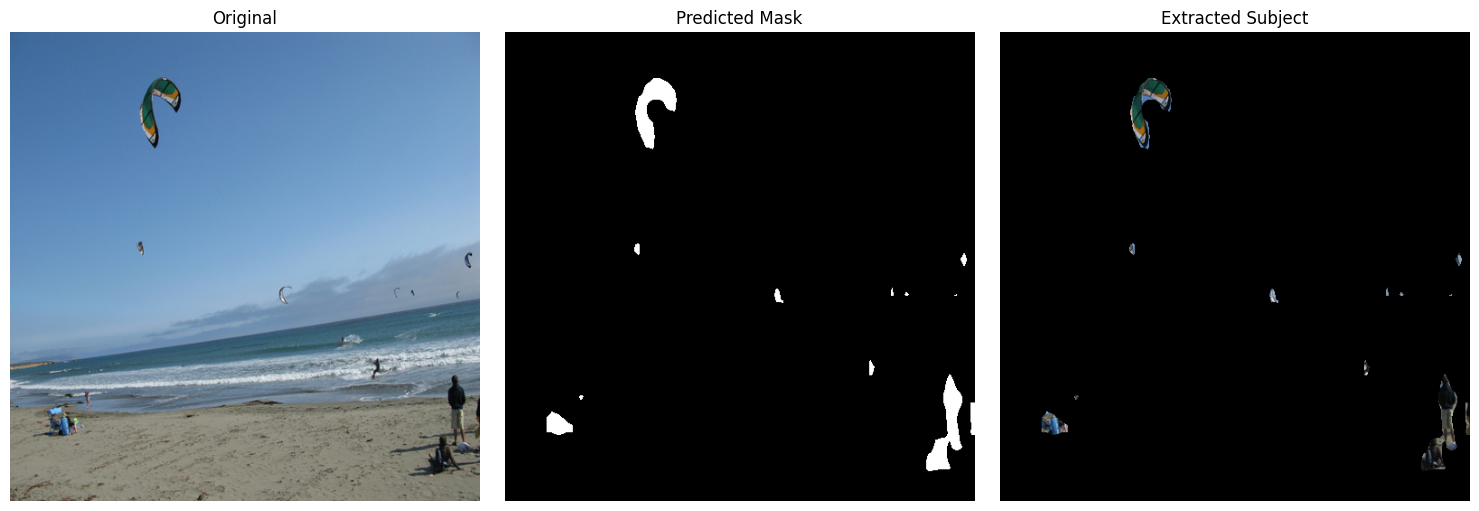

000000017769.jpg: Foreground pixel ratio = 0.462


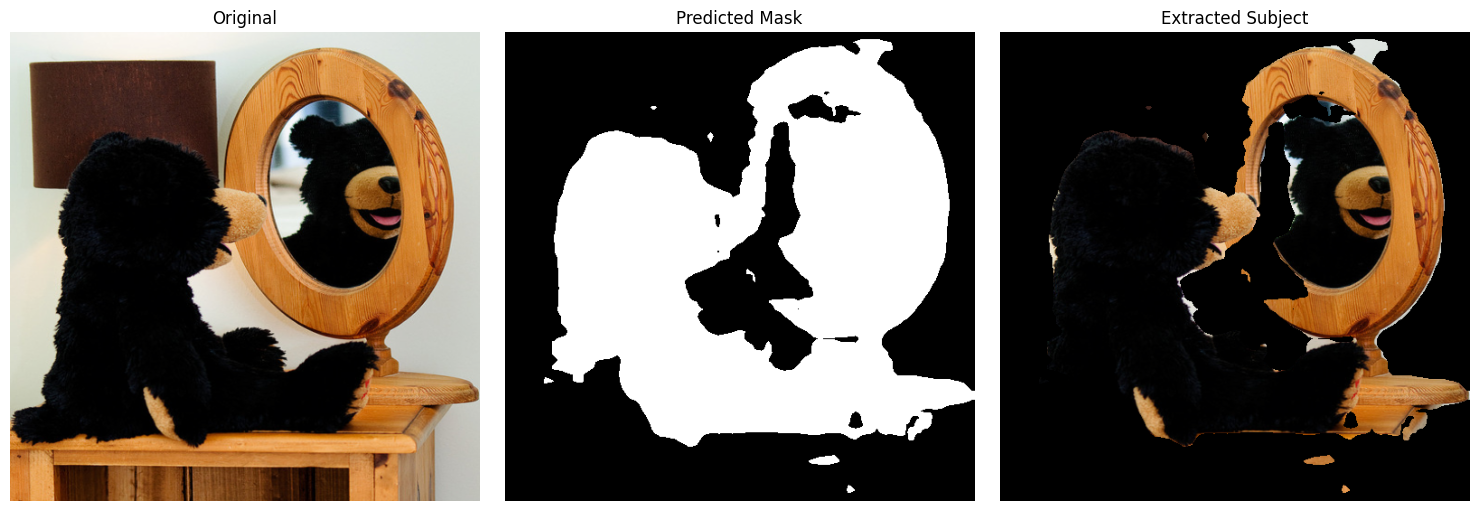

000000281429.jpg: Foreground pixel ratio = 0.101


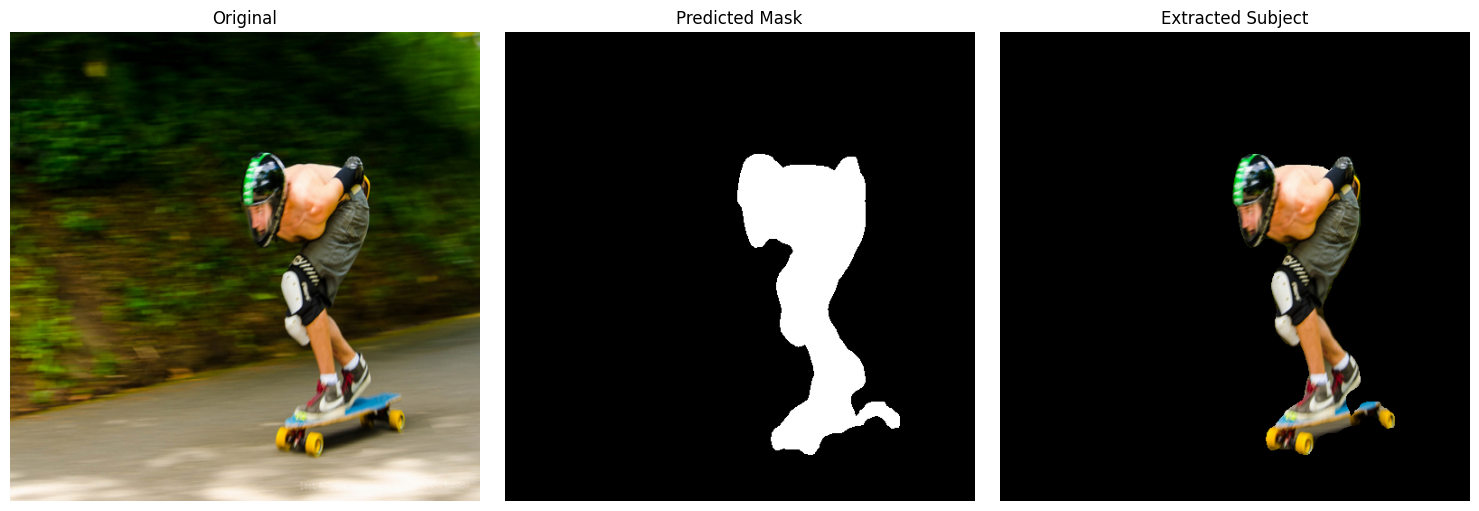

000000091172.jpg: Foreground pixel ratio = 0.051


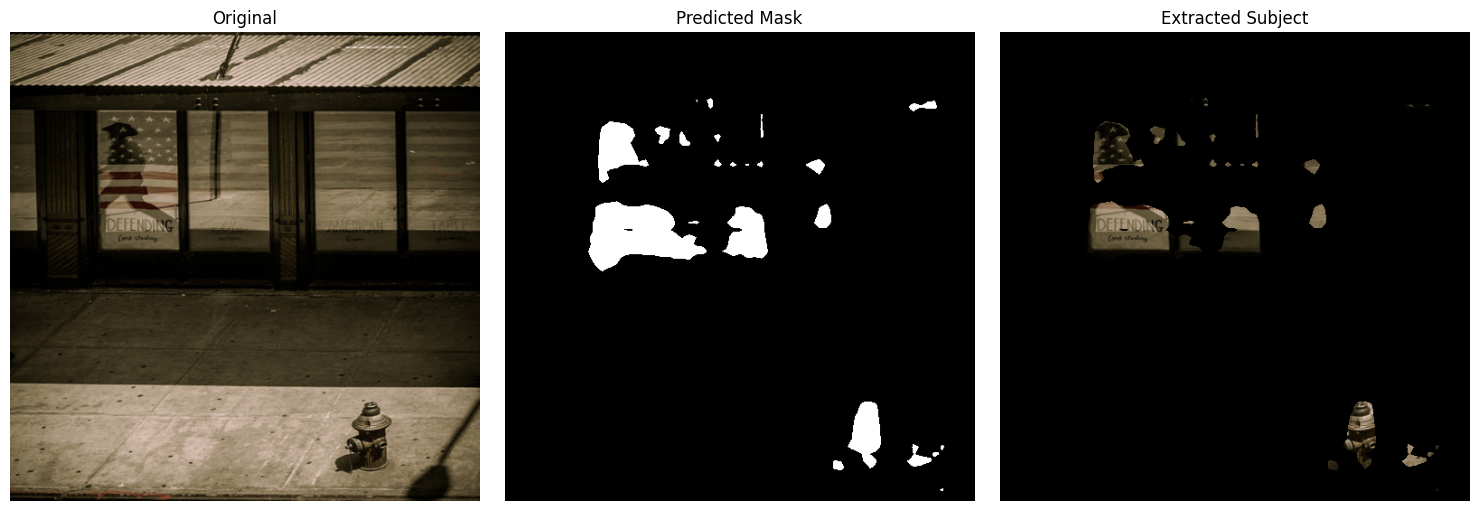

000000411385.jpg: Foreground pixel ratio = 0.178


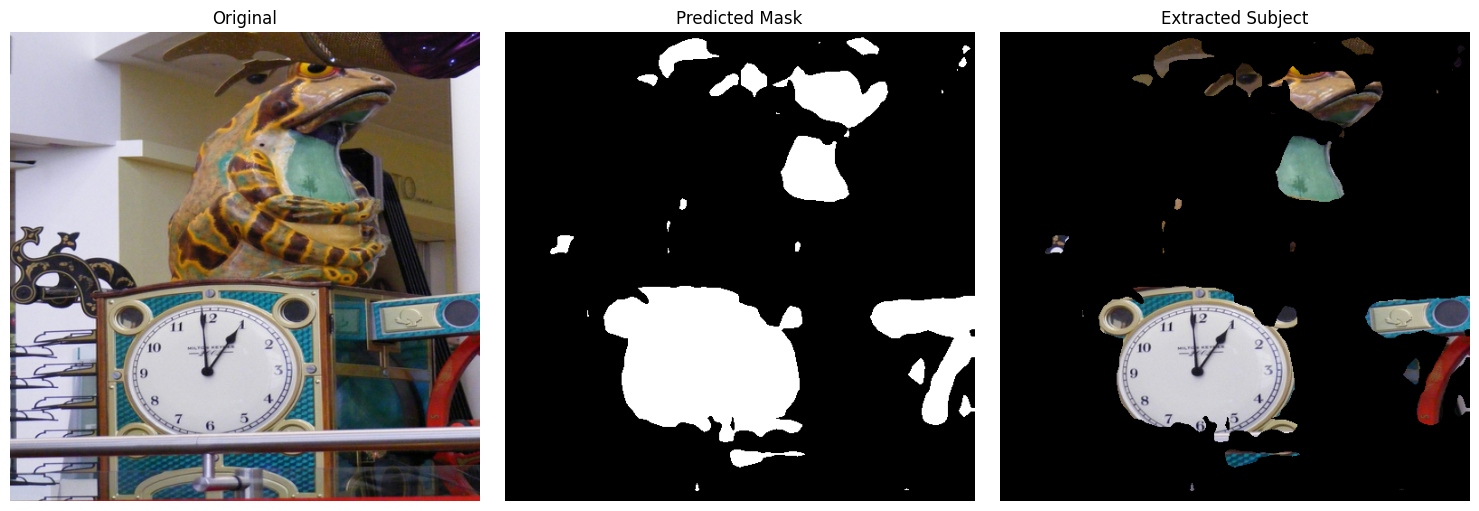

000000307531.jpg: Foreground pixel ratio = 0.103


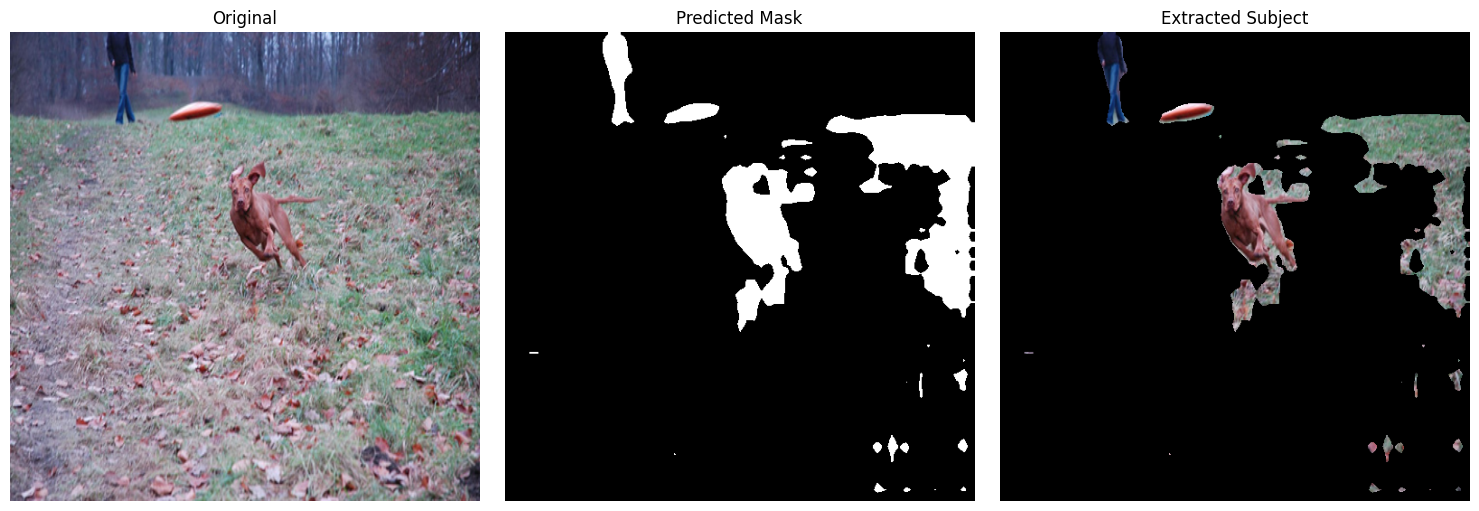

000000308576.jpg: Foreground pixel ratio = 0.556


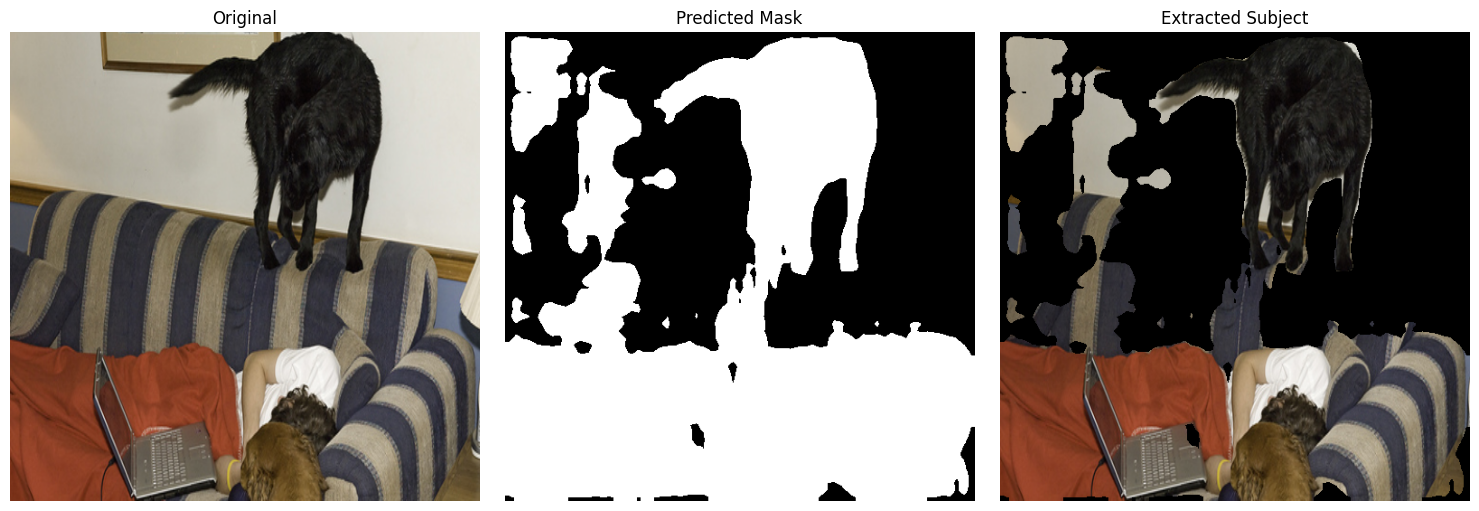

000000232598.jpg: Foreground pixel ratio = 0.452


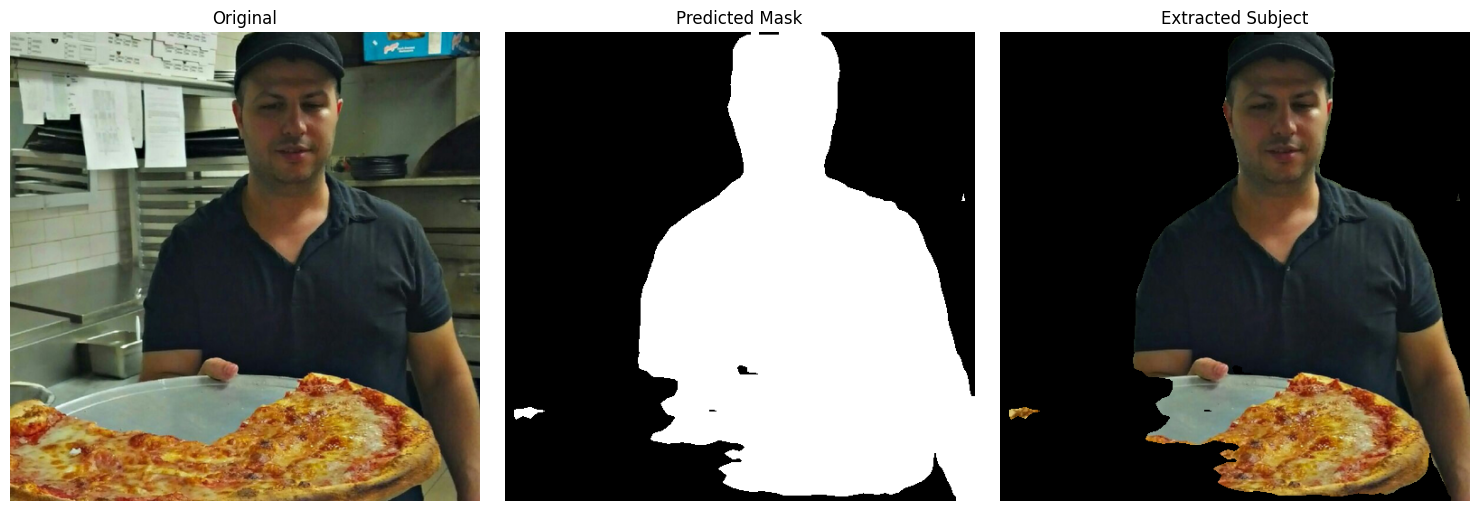

000000476279.jpg: Foreground pixel ratio = 0.006
 000000476279.jpg - Too little foreground, possible missed segmentation


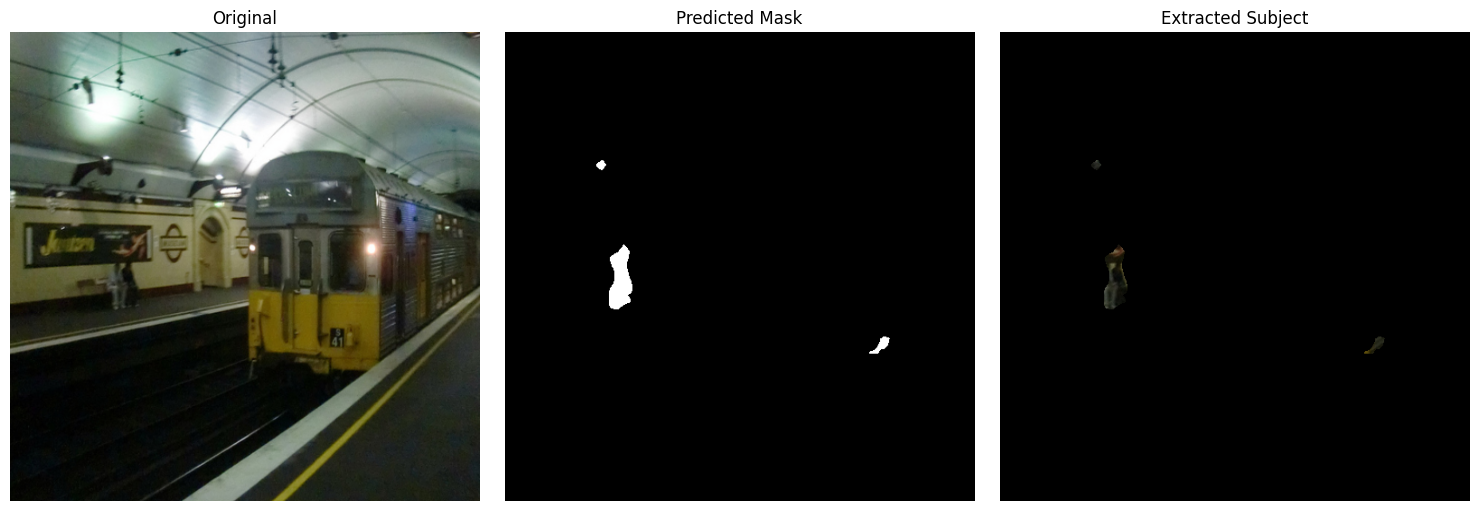

000000324094.jpg: Foreground pixel ratio = 0.621


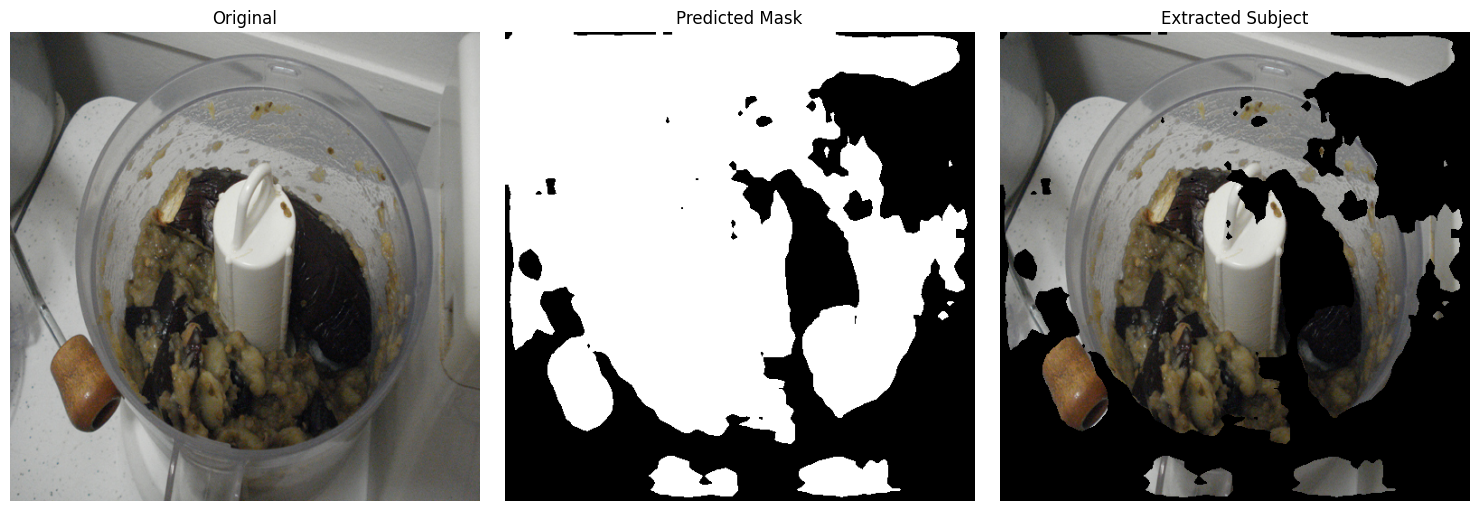

000000050518.jpg: Foreground pixel ratio = 0.170


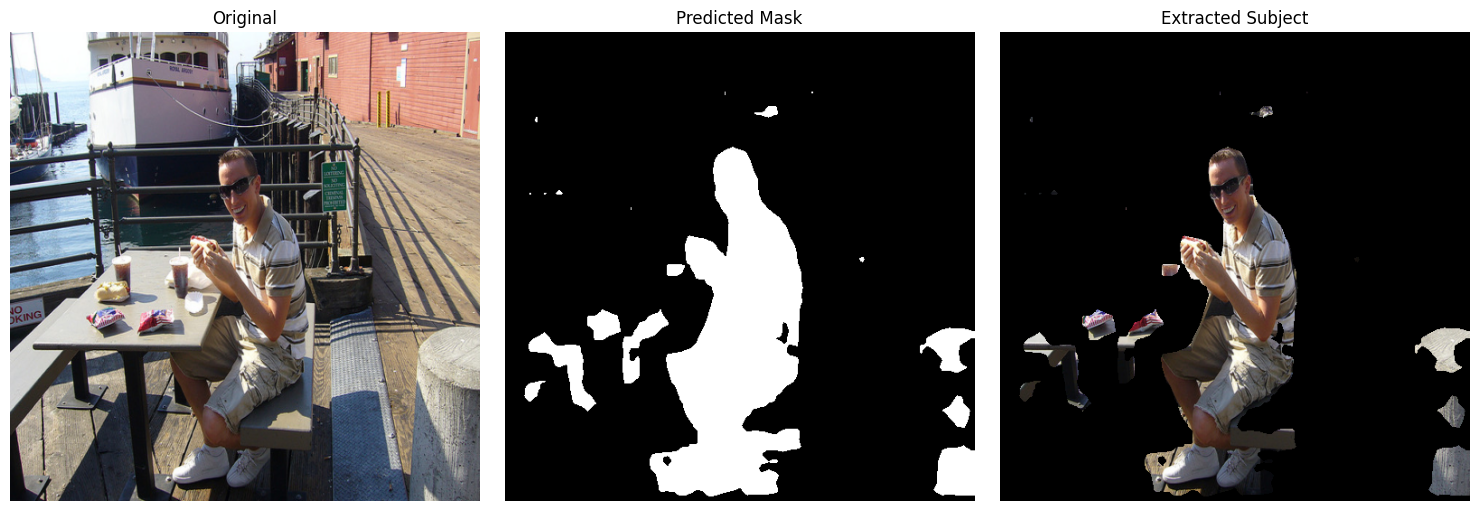

000000475699.jpg: Foreground pixel ratio = 0.174


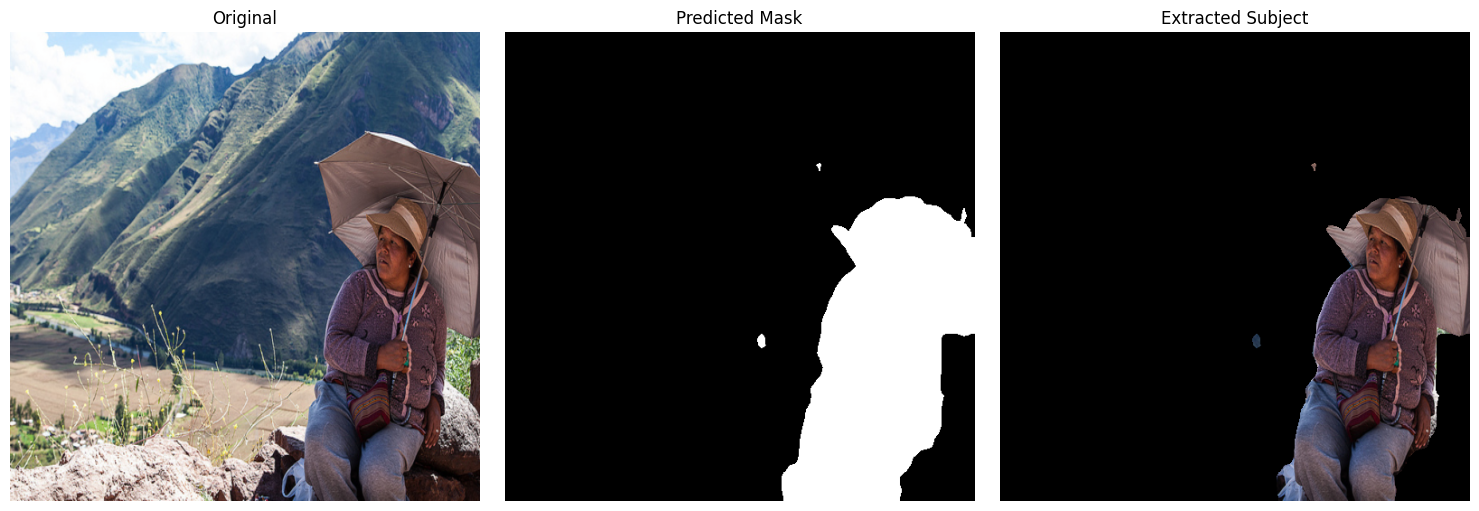

000000556021.jpg: Foreground pixel ratio = 0.091


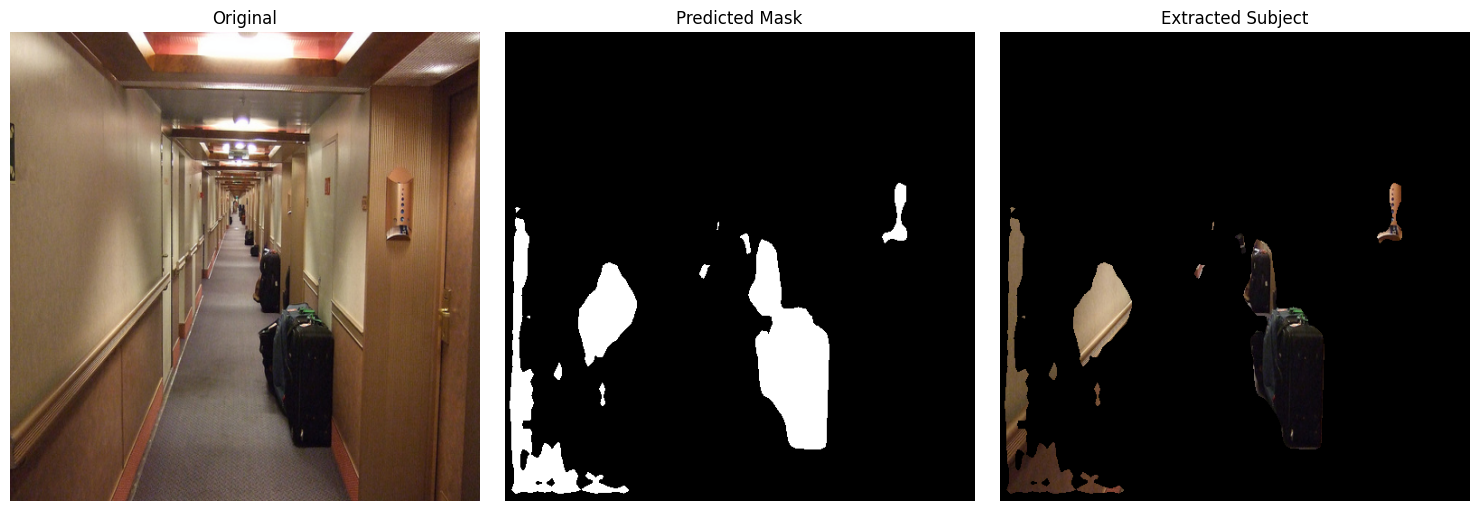

000000478980.jpg: Foreground pixel ratio = 0.139


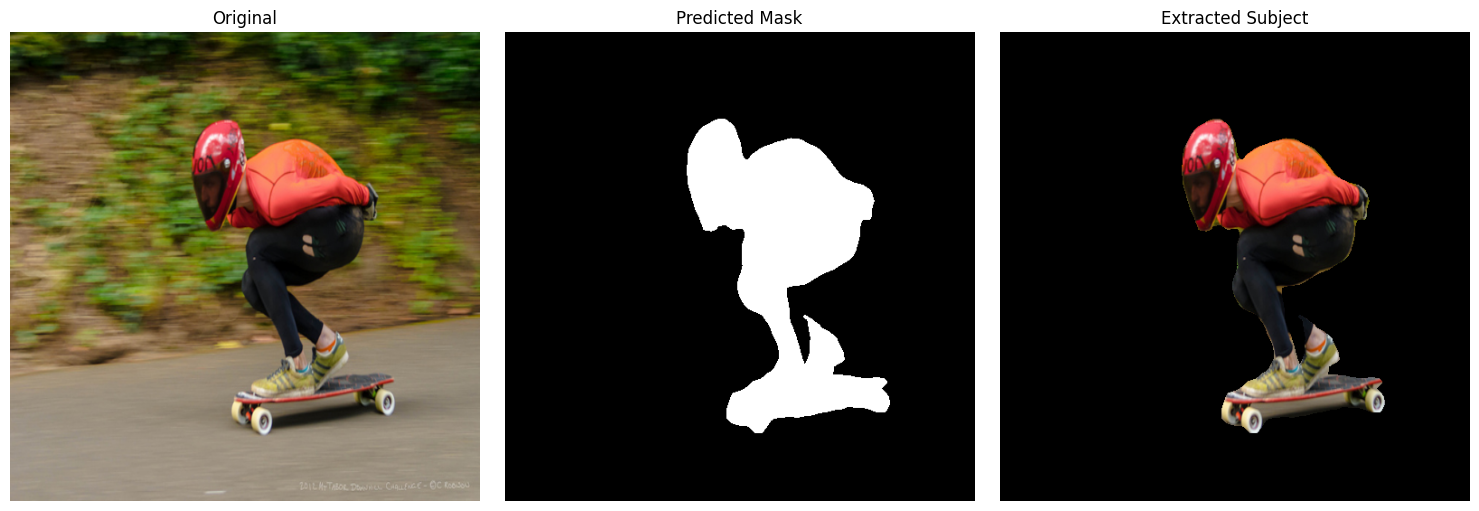

000000372685.jpg: Foreground pixel ratio = 0.552


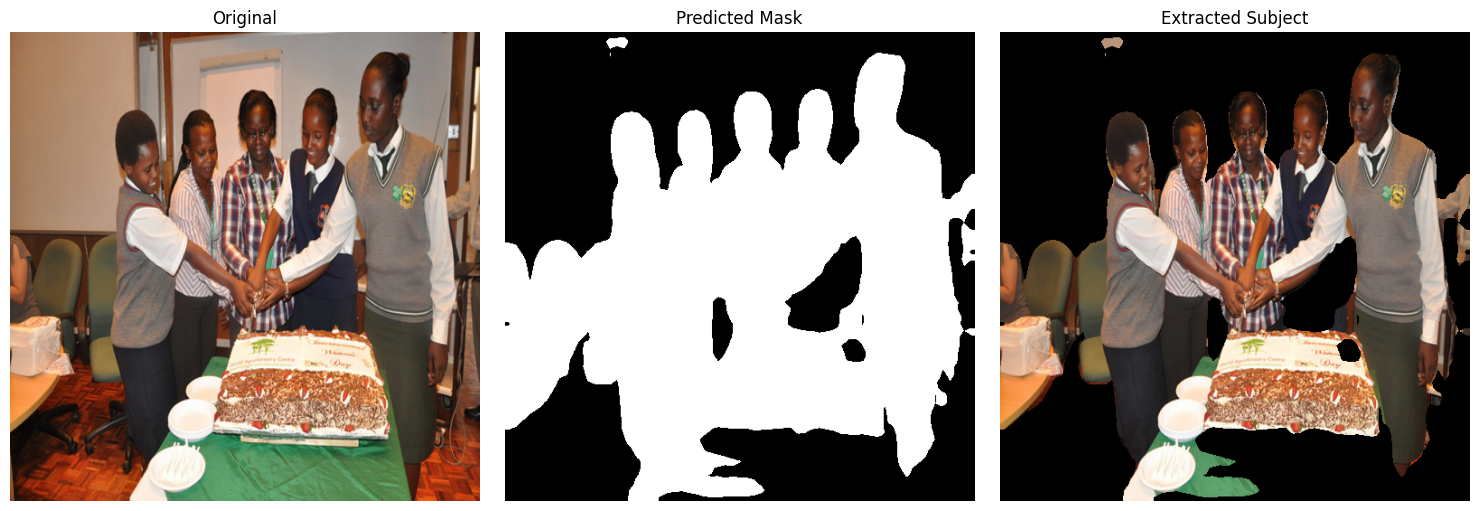


==== Overall Batch Metric ====
Average foreground pixel ratio: 0.245


In [12]:
import torch
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from torchvision.models.segmentation import deeplabv3_resnet50

model_path = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\deeplabv3_resumed_epoch30.pth"
test_images_dir = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\testing images in internet"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 2
model = deeplabv3_resnet50(num_classes=num_classes, aux_loss=False)
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint, strict=False)
model.to(device)
model.eval()


transform = transforms.Compose([
    transforms.Resize((520, 520)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


def denormalize(tensor):
    img = tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    return np.clip(img, 0, 1)

def extract_subject(image, mask):
    masked = image.copy()
    masked[mask == 0] = 0
    return masked

def pseudo_accuracy(mask):
    """Simple pixel ratio as a sanity check"""
    return mask.sum() / mask.size

all_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
sample_images = random.sample(all_images, min(15, len(all_images)))


foreground_ratios = []

for img_name in sample_images:
    img_path = os.path.join(test_images_dir, img_name)
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).to(device).unsqueeze(0)

    with torch.no_grad():
        output = model(img_tensor)['out']
        pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
        pred_bin = (pred_mask > 0).astype(np.uint8)

    acc_ratio = pseudo_accuracy(pred_bin)
    foreground_ratios.append(acc_ratio)
    print(f"{img_name}: Foreground pixel ratio = {acc_ratio:.3f}")

    if acc_ratio < 0.05:
        print(f" {img_name} - Too little foreground, possible missed segmentation")
    elif acc_ratio > 0.95:
        print(f" {img_name} - Too much foreground, possible over-segmentation")

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    img_np = denormalize(img_tensor.squeeze())

    axs[0].imshow(img_np)
    axs[0].set_title("Original")
    axs[0].axis("off")

    axs[1].imshow(pred_bin, cmap="gray")
    axs[1].set_title("Predicted Mask")
    axs[1].axis("off")

    axs[2].imshow(extract_subject(img_np, pred_bin))
    axs[2].set_title("Extracted Subject")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

avg_ratio = np.mean(foreground_ratios)
print("\n==== Overall Batch Metric ====")
print(f"Average foreground pixel ratio: {avg_ratio:.3f}")
